<a href="https://colab.research.google.com/github/Quantum00000/Kaggle_Compititions/blob/main/Kaggle_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


Data import from kaggle

In [25]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5266d2b9f41bb08f77787f1fc1d7ce93'

In [26]:
mkdir -p ~/.kaggle && echo KGAT_5266d2b9f41bb08f77787f1fc1d7ce93 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [27]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('cifar-10neucalssification')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/cifar-10neucalssification


In [28]:
print(os.listdir(path))

['train_labels.csv', 'sample_submission.csv', 'val', 'train', 'test', 'val_labels.csv']


In [29]:
train_labels=pd.read_csv(os.path.join(path,"train_labels.csv"))
train_labels.head()

,filename,label
0,00000.png,3
1,00001.png,7
2,00002.png,7
3,00003.png,1
4,00004.png,1


Extracting img and label number

In [30]:
import cv2

x_train=[]
y_train=[]

for _,row in train_labels.iterrows():

    img_path=os.path.join(path,"train",row["filename"])

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    x_train.append(img)
    y_train.append(row['label'])

x_train=np.array(x_train)
y_train=np.array(y_train)


img=x_train, label=y_train

In [31]:
x_train=torch.tensor(x_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)
x_train.shape

torch.Size([40000, 32, 32, 3])

In [32]:
x_train=x_train/255.0

Comversion in Tensor Dataset and DataLoader


In [33]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(x_train,y_train)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

Classes for label

In [34]:
Classes={
    0:"airplane",
    1:"automobile",
    2:"bird",
    3:"cat",
    4:"deer",
    5:"dog",
    6:"frog",
    7:"horse",
    8:"ship",
    9:"truck"
}

In [35]:
img,label=train_dataset[0]

Label: cat
tensor(3)


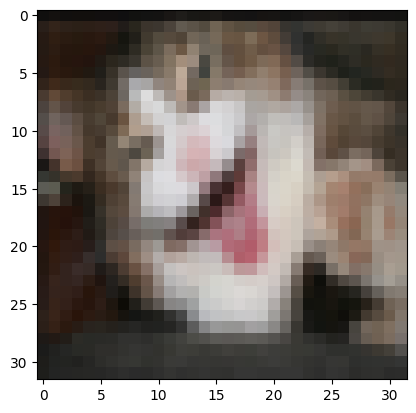

In [36]:
img.shape
# Normalize the image data to the range [0, 1] for proper display
plt.imshow(img )
print("Label:", Classes[label.item()])
print(label)

In [37]:
train_feature_batch,train_label_batch=next(iter(train_loader))

In [38]:
Classes[train_label_batch[0].item()]

'truck'

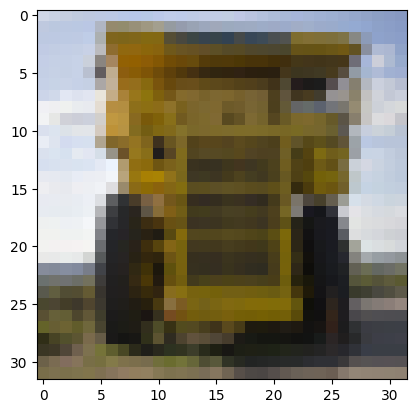

In [39]:
plt.imshow(train_feature_batch[0])

Model Training

In [40]:
class CIFARMODEL_01(nn.Module):

    def __init__(self,input_shape:int,hidden_unit:int,output_shape):
      super().__init__()
      self.block1=nn.Sequential (
          nn.Conv2d(in_channels=input_shape,
                    out_channels=hidden_unit,
                    kernel_size=3,
                    padding=1,
                    stride=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_unit,
                    out_channels=hidden_unit,
                    kernel_size=3,
                    stride=1,
                    padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
                       stride=2)
      )
      self.block2=nn.Sequential(
          nn.Conv2d(in_channels=hidden_unit,
                    out_channels=hidden_unit,
                    kernel_size=3,
                    stride=1,
                    padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_unit,
                    out_channels=hidden_unit,
                    kernel_size=3,
                    stride=1,
                    padding=1),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2,
                       stride=2)
      )
      self.Classifier=nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=hidden_unit*8*8,
                    out_features=output_shape)
      )
    def forward(self,x:torch.Tensor):
      x = x.permute(0, 3, 1, 2) # Permute dimensions for Conv2d
      x=self.block1(x)
      x=self.block2(x)
      x=self.Classifier(x)
      return x

# Model training and Model evaluation


In [41]:
model01=CIFARMODEL_01(
    input_shape=3, # Changed input_shape to 3 for RGB channels
    hidden_unit=1024,
    output_shape=64
)
model01

CIFARMODEL_01(
  (block1): Sequential(
    (0): Conv2d(3, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=64, bias=True)
  )
)

Optimizer

In [42]:
optimizer=torch.optim.SGD(params=model01.parameters(),lr=0.001)

Loss Function

In [43]:
Loss_fn=nn.CrossEntropyLoss()

Accuracy function

In [44]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=correct/len(y_pred)
  return acc

Model training

In [46]:
def Train_model(
    model:torch.nn.Module,
    data_loader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    optimizer:torch.optim.Optimizer,
    accuracy_fn,
    device:torch.device=torch.device
):

  torch.manual_seed(42)

  epoches=3

  for epoch in range(epoches):
    train_loss,train_acc=0,0
    model.to(device)
    for batch,((X,y)) in enumerate(data_loader):
      X,y=X.to(device),y.to(device)
      y_pred=model(X)
      loss=loss_fn(y_pred,y)
      train_loss+=loss.item()
      train_acc+=accuracy_fn(y,y_pred.argmax(dim=1))
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    train_loss/=len(data_loader)
    train_acc/=len(data_loader)
    print(f"Loss:{train_loss:.5f}|Accuracy:{train_acc:.5f}")


In [47]:
Train_model(
    model=model01,
    data_loader=train_loader,
    loss_fn=Loss_fn,
    optimizer=optimizer,
    accuracy_fn=accuracy_fn,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

Loss:2.32126|Accuracy:0.18635
Loss:2.01052|Accuracy:0.28642
Loss:1.88797|Accuracy:0.33515
